In [1]:
import numpy as np
import pandas as pd
import re
import random
import contractions
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from keras.models import Model
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SimpleRNN, Input, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from functions import preprocess, export_weights, export_matrix_to_mem

# Importação e processamento do Dataset

In [2]:
df = pd.read_csv("IMDB Dataset.csv")

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
random_num = random.randrange(len(df))

sample_text = df.iloc[random_num]['review']
sample_text

"When the long running 'Happy Ever After' came to an end, its characters- 'Terry & June Fletcher' were revived for the longer running and more popular sequel- 'Terry & June', although their surnames were changed from Fletcher to Medford.<br /><br />Terry has received a new job and as a result, he and June move to Purley where they end up in all manner of scrapes- unwanted guests dropping by to visit at an inconvenient moment, the boss inviting himself to dinner and Terry trying to chance his arm at D.I.Y but cocking it up each time. A fellow IMDb user branded this show as 'not clever' and 'never well written'. Fair enough, it wasn't clever, but that was the whole point. As for 'never well written'- some of the episodes were pretty substandard, I will admit, but overall I found it to be extremely well written, highly amusing and very well acted.<br /><br />It was warm hearted slapstick, not dissimilar to the later B.B.C sitcom 'Keeping Up Appearances'. Eight different writers contribute

In [5]:
print(preprocess(df.iloc[random_num]['review']))

long running happy ever came end character terry june fletcher revived longer running popular sequel terry june although surname changed fletcher medford terry received new job result june move purley end manner scrape unwanted guest dropping visit inconvenient moment bos inviting dinner terry trying chance arm cocking time fellow imdb user branded show clever never well written fair enough clever whole point never well written episode pretty substandard admit overall found extremely well written highly amusing well acted warm hearted slapstick dissimilar later sitcom keeping appearance eight different writer contributed nine series giving show plenty scope terry scott comic genius well proved production hugh carry film course june whitfield likewise comedy legend right enjoy modern show still game catherine tate show legit empty even enjoyed alternative comedy naked video young one comic strip present inclined enjoy vintage comedy humour need think excellent feeling want lift record t

In [6]:
df['review'] = df['review'].apply(preprocess)

In [7]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [8]:
n_words = [len(i.split(" ")) for i in df['review']]
print(f"Quantidade média de tokens {np.mean(n_words)}")
print(f"Mediana de tokens {np.median(n_words)}")

Quantidade média de tokens 116.49538
Mediana de tokens 86.0


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [10]:
vocab_size = 20000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

In [11]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [38]:
max_len = 120

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# LSTM

In [67]:
lstm_model = Sequential()

lstm_model.add(Input(shape=(max_len,)))

lstm_model.add(Embedding(input_dim=vocab_size, output_dim=4))
lstm_model.add(SpatialDropout1D(0.3))

lstm_model.add((LSTM(8, dropout=0.3)))

lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(8, activation='relu'))
lstm_model.add(Dropout(0.4))

lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

lstm_model.build(input_shape=(None, max_len))
lstm_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 120, 4)         │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_8             │ (None, 120, 4)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 8)              │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,497 (314.44 KB)

 Trainable params: 80,497 (314.44 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

In [69]:
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=1000,
    batch_size=128,   
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/1000


250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5726 - loss: 0.6754 - val_accuracy: 0.7945 - val_loss: 0.5479 - learning_rate: 5.0000e-04
Epoch 2/1000
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.7877 - loss: 0.4864 - val_accuracy: 0.8525 - val_loss: 0.3540 - learning_rate: 5.0000e-04
Epoch 3/1000
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8364 - loss: 0.3966 - val_accuracy: 0.8725 - val_loss: 0.3096 - learning_rate: 5.0000e-04
Epoch 4/1000
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8563 - loss: 0.3535 - val_accuracy: 0.8756 - val_loss: 0.3007 - learning_rate: 5.0000e-04
Epoch 5/1000
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8706 - loss: 0.3254 - val_accuracy: 0.8784 - val_loss: 0.2966 - learning_rate: 5.0000e-04
Epoch 6/1000
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.8788 - loss: 0.2988 - val_accuracy: 0.8766 - val_loss: 0.3055 - learning_rate: 5.0000e-04


In [71]:
lstm_model.save_weights("lstm_modelo_pesado_2.weights.h5")

In [72]:

lstm_model.load_weights("lstm_modelo_pesado_2.weights.h5")

In [73]:
#Comentado por não ser acessário treinar rede novamente

""" plt.figure(figsize=(10,5))

plt.plot(lstm_history.history['accuracy'], label='Train Acc')
plt.plot(lstm_history.history['val_accuracy'], label='Val Acc')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()"""

' plt.figure(figsize=(10,5))\n\nplt.plot(lstm_history.history[\'accuracy\'], label=\'Train Acc\')\nplt.plot(lstm_history.history[\'val_accuracy\'], label=\'Val Acc\')\n\nplt.title("Model Accuracy")\nplt.xlabel("Epoch")\nplt.ylabel("Accuracy")\nplt.legend()\nplt.show()'

In [74]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8807 - loss: 0.2848
Test Accuracy: 0.8806999921798706


# Matriz de Confusão

#### Acurácia de 0.8798

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


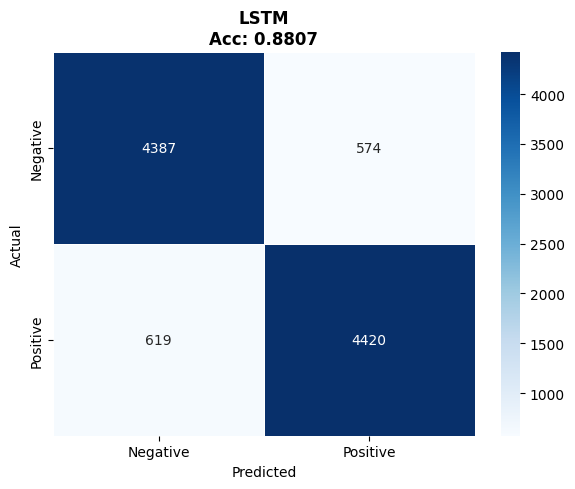

In [75]:
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    linewidths=0.5,
    linecolor='white'
)

acc = (y_pred_lstm == y_test.values).mean()

plt.title(f'LSTM\nAcc: {acc:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# Resultados da Classificação

In [76]:
for name, pred in zip(['LSTM'], [ y_pred_lstm]):
    print(f"{'='*45}")
    print(f"  {name} — Classification Report")
    print(f"{'='*45}")
    print(classification_report(y_test, pred, target_names=['Negative','Positive']))

  LSTM — Classification Report
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88      4961
    Positive       0.89      0.88      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



# Teste de Outputs


In [77]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)

x = X_test_pad[0].tolist()

outputs = inspection_model.predict(np.array([x]))

# salva em txt
with open("layer_outputs_simplified_model.txt", "w", encoding="utf-8") as f:

    for layer, output in zip(lstm_model.layers, outputs):

        f.write(f"\n{'='*60}\n")
        f.write(f"Camada: {layer.name}\n")
        f.write(f"Shape: {output.shape}\n")
        f.write(f"{'='*60}\n\n")

        # converte numpy array para string
        np.set_printoptions(threshold=np.inf)

        f.write(np.array2string(
            output,
            separator=', ',
            precision=6
        ))

        f.write("\n\n")

print("Outputs salvos em layer_outputs_simplified_model.txt")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step
Outputs salvos em layer_outputs_simplified_model.txt


# Exportação de Pesos

In [78]:
export_weights(lstm_model, mode='lstm', output_file="../../Geral Tests SystemVerilog/Simplified Neural Network 2.0/weights.mem")


print("\n" + "#"*60)
print("CONCLUIDO!")
print("#"*60)


MODO LSTM: Exportando pesos a partir da primeira LSTM
Ignorando: Embedding e SpatialDropout1D

Camada 0: LSTM
  addr=0x08000 Wx_input[0][0] = -0.190384
  addr=0x08001 Wx_input[0][1] = -0.050118
  addr=0x08080 Wx_input[1][0] = 0.115906
  addr=0x08081 Wx_input[1][1] = 0.214759
  addr=0x08040 Wh_input[0][0] = -0.149988
  addr=0x08041 Wh_input[0][1] = -0.075867
  addr=0x080C0 Wh_input[1][0] = -0.120434
  addr=0x080C1 Wh_input[1][1] = 0.011628
  addr=0x18000 bias_input[0] = 0.147865
  addr=0x18080 bias_input[1] = 0.103521
  addr=0x0A000 Wx_forget[0][0] = 0.125517
  addr=0x0A001 Wx_forget[0][1] = 0.108646
  addr=0x0A080 Wx_forget[1][0] = -0.264144
  addr=0x0A081 Wx_forget[1][1] = 0.068558
  addr=0x0A040 Wh_forget[0][0] = 0.143196
  addr=0x0A041 Wh_forget[0][1] = -0.210198
  addr=0x0A0C0 Wh_forget[1][0] = -0.158059
  addr=0x0A0C1 Wh_forget[1][1] = 0.212765
  addr=0x1A000 bias_forget[0] = 1.124245
  addr=0x1A080 bias_forget[1] = 1.086102
  addr=0x0C000 Wx_candidate[0][0] = -0.513750
  addr=0x

# Teste Global

In [79]:
FRAC = 16
SCALE = 1 << FRAC

INT32_MAX = np.int32(2**31 - 1)
INT32_MIN = np.int32(-(2**31))

def float_to_q16(val):
    if np.isnan(val):
        return np.int32(0)
    if np.isposinf(val):
        return INT32_MAX
    if np.isneginf(val):
        return INT32_MIN
    fixed = np.round(val * SCALE)
    return np.int32(fixed)


In [80]:
def export_matrix_to_mem(matrix,result,ground_result, output_file="matrix.mem"):
    mem = {}
    
    for linha_idx in range(matrix.shape[0]):
        for col_idx in range(4):
            addr = (linha_idx << 2) | col_idx
            valor = matrix[linha_idx, col_idx]
            valor_q16 = float_to_q16(valor)  # sua função original
            mem[addr] = valor_q16
    
    # ESCREVE EXATAMENTE COMO NO SEU CÓDIGO ORIGINAL
    with open(output_file, "w") as f:
        line = 0
        result_hex = float_to_q16(result)
        for addr in sorted(mem.keys()):
            val = np.int32(mem[addr])  # ← igual ao original
            if line == 0:
                f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X} {int(result_hex) & 0xFFFFFFFF:08X}  {int(ground_result) & 0xFFFFFFFF:01X}   \n")
            else:
                f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X}\n")
            line+=1
    print(f"Arquivo salvo: {output_file}")
    return mem

In [96]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)
#total = len(y_pred_lstm)
total = 20

valores_out_embbeding = []
valores_out_lstm = []
valores_out_relu = []
valores_out_sigmoid = []

for i in range(total):
    x = np.array([X_test_pad[i].tolist()])

    outputs = inspection_model.predict(x)
    
    export_matrix_to_mem(outputs[0][0], outputs[6][0][0], y_test.values[i], f"../../Geral Tests SystemVerilog/Simplified Neural Network 2.0/Global Processing/dados_{i}.mem")

    valores_out_embbeding += outputs[0].reshape(-1).tolist()
    valores_out_lstm += outputs[2].reshape(-1).tolist()
    valores_out_relu += outputs[4].reshape(-1).tolist()
    valores_out_sigmoid += outputs[6].reshape(-1).tolist()

    print(f"{i} de {total}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 681ms/step
Arquivo salvo: ../../Geral Tests SystemVerilog/Simplified Neural Network 2.0/Global Processing/dados_0.mem
0 de 20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Arquivo salvo: ../../Geral Tests SystemVerilog/Simplified Neural Network 2.0/Global Processing/dados_1.mem
1 de 20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Arquivo salvo: ../../Geral Tests SystemVerilog/Simplified Neural Network 2.0/Global Processing/dados_2.mem
2 de 20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Arquivo salvo: ../../Geral Tests SystemVerilog/Simplified Neural Network 2.0/Global Processing/dados_3.mem
3 de 20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Arquivo salvo: ../../Geral Tests SystemVerilog/Simplified Neural Network 2.0/Global Processing/dados_4.mem
4 de 20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Arquivo salvo: ../../Geral Tests SystemVerilog/Simplified Neural Network 2.0/Global Processing/dados_5.mem
5 de 20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Arquivo salvo: ../../Geral Tests SystemVeri

In [95]:
lstm_model.weights[5]

<Variable path=sequential_8/dense_16/bias, shape=(8,), dtype=float32, value=[0.1561536  0.14151272 0.1914747  0.19049992 0.13138448 0.12198814
 0.12595469 0.14653066]>

C:\Users\jose.sales\AppData\Local\Temp\ipykernel_32112\1711446782.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  plt.hist(np.array(lstm_model.weights[5]).reshape(-1), bins=50, edgecolor='black')


(array([1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 2.]),
 array([0.12198814, 0.12337787, 0.1247676 , 0.12615733, 0.12754707,
        0.1289368 , 0.13032652, 0.13171625, 0.13310599, 0.13449572,
        0.13588545, 0.13727519, 0.13866492, 0.14005464, 0.14144439,
        0.14283411, 0.14422384, 0.14561357, 0.14700331, 0.14839303,
        0.14978276, 0.1511725 , 0.15256223, 0.15395196, 0.15534168,
        0.15673143, 0.15812115, 0.15951088, 0.16090062, 0.16229035,
        0.16368008, 0.16506982, 0.16645955, 0.16784927, 0.169239  ,
        0.17062873, 0.17201847, 0.1734082 , 0.17479792, 0.17618766,
        0.17757739, 0.17896712, 0.18035686, 0.18174659, 0.18313631,
        0.18452606, 0.18591578, 0.18730551, 0.18869525, 0.19008496,
        0.19147471]),
 <BarContainer object of 50 artists>)

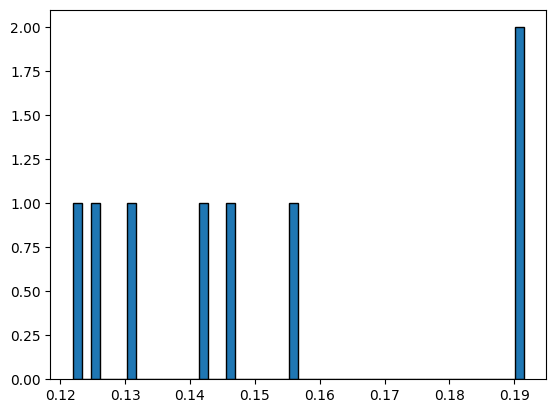

In [97]:
plt.hist(np.array(lstm_model.weights[5]).reshape(-1), bins=50, edgecolor='black')

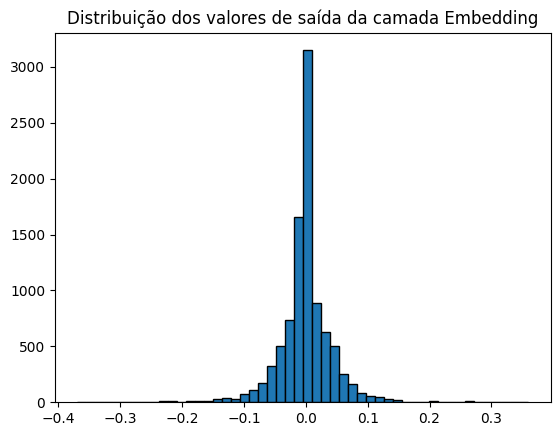

In [98]:
plt.title("Distribuição dos valores de saída da camada Embedding")
plt.hist(valores_out_embbeding, bins=50, edgecolor='black')
plt.show()

In [120]:
veri = pd.read_csv("resultados_lstm.txt",skiprows=3,header=None,sep=" ")[11].to_list()

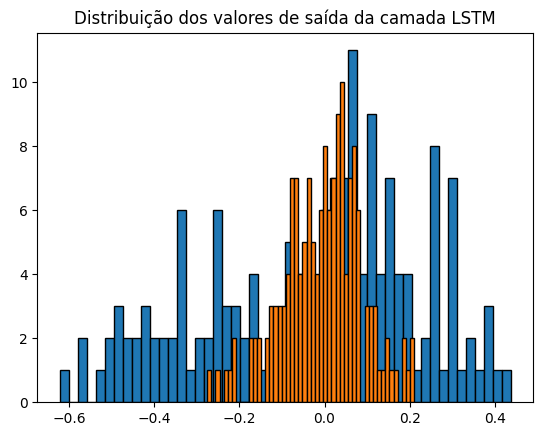

In [121]:
plt.title("Distribuição dos valores de saída da camada LSTM")
plt.hist(valores_out_lstm, bins=50, edgecolor='black')
plt.hist(veri, bins=50, edgecolor='black')

plt.show()

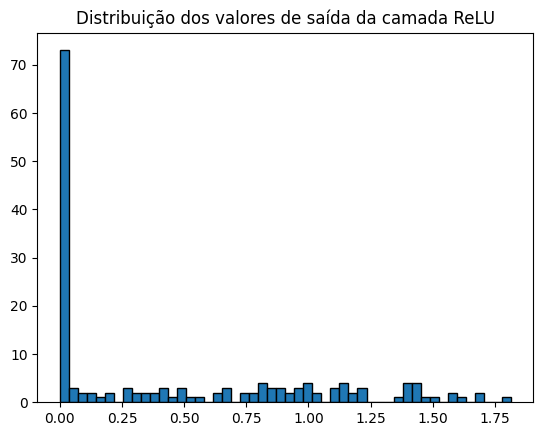

In [100]:
plt.title("Distribuição dos valores de saída da camada ReLU")
plt.hist(valores_out_relu, bins=50, edgecolor='black')
plt.show()

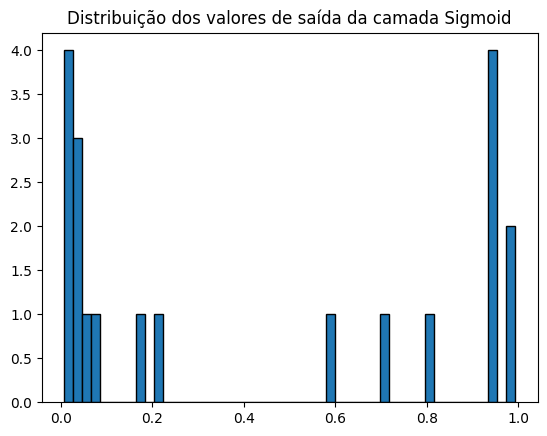

In [101]:
plt.title("Distribuição dos valores de saída da camada Sigmoid")
plt.hist(valores_out_sigmoid, bins=50, edgecolor='black')
plt.show()